## Librerías.

In [ ]:
import sys
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'
if project_path not in sys.path:
    sys.path.append(project_path)

Mounted at /content/drive


In [ ]:
# Configuramos direcciones.
data_dir = os.path.join(project_path, 'data/binary')
path_base = os.path.join(project_path, 'models/celeba_base.h5')

In [ ]:
# Creamos los generadores.
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)

# Generador de entrenamiento.
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training',
    shuffle=True)

# Generador de validación.
valid_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False)

Found 98 images belonging to 2 classes.
Found 24 images belonging to 2 classes.


In [ ]:
# Cargamos el modelo preentrenado.
base_model = tf.keras.models.load_model(path_base)

# Creamos el extractor de características.
feature_extractor = tf.keras.Sequential(base_model.layers[:8])

feature_extractor.trainable = False

# Añadimos el mejor clasificador.
inputs = layers.Input(shape=(224, 224, 3))
x = feature_extractor(inputs)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.Dropout(.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=inputs, outputs=output)

In [ ]:
# Compilamos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [ ]:
# Vemos la arquitectura del modelo.
print("Arquitectura del Modelo:")
model.summary()

Arquitectura del Modelo:


Model: "functional_103"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 12, 12, 128)    │       240,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,359,553 (9.00 MB)

 Non-trainable params: 240,832 (940.75 KB)

In [ ]:
# Entrenamos.
ruta_mejor_modelo = os.path.join(project_path, 'models/mi_reconocedor.h5')

early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    filepath=ruta_mejor_modelo,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

history_final = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
    callbacks=[early_stopping, checkpoint],
    verbose=1)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.6652 - loss: 3.1198

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 653ms/step - accuracy: 0.6665 - loss: 3.1126 - val_accuracy: 0.5833 - val_loss: 2.8038
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.7884 - loss: 2.7040 - val_accuracy: 0.5417 - val_loss: 2.4846
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9417 - loss: 2.3562

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.9423 - loss: 2.3508 - val_accuracy: 0.6250 - val_loss: 2.2044
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.9473 - loss: 2.0689 - val_accuracy: 0.5833 - val_loss: 1.9772
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - accuracy: 0.9758 - loss: 1.8011 - val_accuracy: 0.6250 - val_loss: 1.8075
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - accuracy: 0.9300 - loss: 1.6159 - val_accuracy: 0.5000 - val_loss: 1.6503
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.9248 - loss: 1.4303 - val_accuracy: 0.6250 - val_loss: 1.5380
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 294ms/step - accuracy: 0.9602 - loss: 1.2602 - val_accuracy: 0.5833 - val_loss: 1.4659
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 305ms/step - accuracy: 0.9260 - loss: 1.1778 - val_accuracy: 0.6250 - val_loss: 1.3537
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - accuracy: 0.9716 - loss: 1.0203 - val_accuracy: 0.6250 - val

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.9710 - loss: 0.6353 - val_accuracy: 0.6667 - val_loss: 1.0656
Epoch 19/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 255ms/step - accuracy: 0.9539 - loss: 0.6227 - val_accuracy: 0.6250 - val_loss: 1.1323
Epoch 20/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.9572 - loss: 0.6074 - val_accuracy: 0.6250 - val_loss: 1.0715
Epoch 21/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.9683 - loss: 0.5606 - val_accuracy: 0.6250 - val_loss: 1.0493
Epoch 22/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9669 - loss: 0.5572

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.9671 - loss: 0.5563 - val_accuracy: 0.7083 - val_loss: 1.0671
Epoch 23/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.9681 - loss: 0.5440 - val_accuracy: 0.6250 - val_loss: 1.0536
Epoch 24/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.9378 - loss: 0.5107 - val_accuracy: 0.6250 - val_loss: 1.0007
Epoch 25/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 305ms/step - accuracy: 0.9536 - loss: 0.4968 - val_accuracy: 0.6250 - val_loss: 0.9647
Epoch 26/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.9461 - loss: 0.4858 - val_accuracy: 0.5833 - val_loss: 1.0490
Epoch 27/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 330ms/step - accuracy: 0.9096 - loss: 0.4933 - val_accuracy: 0.6250 - val_loss: 1.0296
Epoch 28/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.9632 - loss: 0.4597 - val_accuracy: 0.6667 - val_loss: 0.9804
Epoch 29/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - accuracy: 0.9815 - loss: 0.4375 - val_accuracy: 0.6250

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - accuracy: 0.9764 - loss: 0.3646 - val_accuracy: 0.7500 - val_loss: 0.9419
Epoch 38/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - accuracy: 0.9881 - loss: 0.3503 - val_accuracy: 0.6667 - val_loss: 0.9689
Epoch 39/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.9816 - loss: 0.3244 - val_accuracy: 0.5833 - val_loss: 1.0534
Epoch 40/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.9641 - loss: 0.3388 - val_accuracy: 0.6250 - val_loss: 0.9613
Epoch 41/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - accuracy: 0.9907 - loss: 0.3345 - val_accuracy: 0.6667 - val_loss: 0.8836
Epoch 42/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.9627 - loss: 0.3602 - val_accuracy: 0.5833 - val_loss: 0.9081
Epoch 43/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.9934 - loss: 0.3259 - val_accuracy: 0.6667 - val_loss: 0.9503
Epoch 44/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.9985 - loss: 0.3195 - val_accuracy: 0.6250

Gráficas guardadas en: /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/training_metrics.png


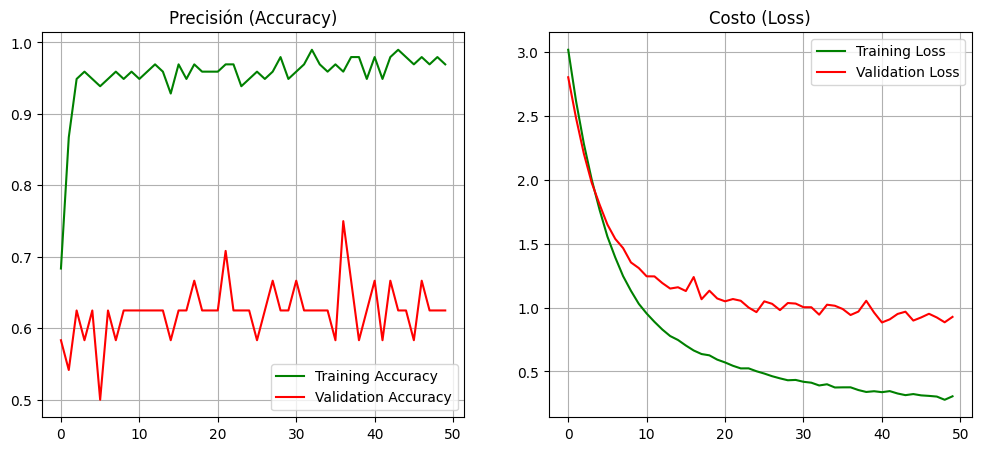

In [ ]:
# Gráficas de costo y presición.
acc = history_final.history['accuracy']
val_acc = history_final.history['val_accuracy']
loss = history_final.history['loss']
val_loss = history_final.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de Accuracy.
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, color='green', label='Training Accuracy')
plt.plot(epochs_range, val_acc, color='r', label='Validation Accuracy')
plt.title('Precisión (Accuracy)')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica de Loss (Costo).
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, color='green', label='Training Loss')
plt.plot(epochs_range, val_loss, color='r', label='Validation Loss')
plt.title('Costo (Loss)')
plt.legend(loc='upper right')
plt.grid(True)

imagen_metrics = os.path.join(project_path, 'training_metrics.png')
plt.savefig(imagen_metrics)
print(f"Gráficas guardadas en: {imagen_metrics}")

plt.show()